In [1]:
# ============================================================
# ETP Market Making — Module 2: Restrike Monitor
# Underlying: ICE Brent 2nd month future (BZ=F proxy)
# Restrike trigger: -20% intraday on the underlying
# Calibrated on: 23 March 2026 (Trump/Iran spike)
# ============================================================

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

plt.style.use('dark_background')
plt.rcParams.update({
    'font.family': 'monospace',
    'axes.facecolor':  '#0d1117',
    'figure.facecolor': '#0d1117',
    'axes.edgecolor': '#30363d',
    'axes.labelcolor': '#8b949e',
    'xtick.color': '#8b949e',
    'ytick.color': '#8b949e',
    'grid.color': '#21262d',
    'grid.linewidth': 0.5,
    'text.color': '#e6edf3'
})

print("✓ Libraries loaded")

✓ Libraries loaded


In [2]:
# ============================================================
# DATA + RESTRIKE PARAMETERS
# ============================================================

ticker = yf.Ticker("BZ=F")
df = ticker.history(period="1d", interval="1m")

# Clean
df.index = df.index.tz_convert("Europe/London")
df = df[["Open", "High", "Low", "Close", "Volume"]].copy()
df.columns = df.columns.str.lower()

# Core parameters
OPEN_PRICE = df['close'].iloc[0]
RESTRIKE_THRESHOLD = -20.0          # % on the underlying
RESTRIKE_BARRIER = OPEN_PRICE * (1 + RESTRIKE_THRESHOLD / 100)
WARN_THRESHOLD = -16.0              # % — warning zone (80% of restrike)
WARN_BARRIER = OPEN_PRICE * (1 + WARN_THRESHOLD / 100)
LEVERAGE = 3

# Intraday drawdown from open
df['drawdown'] = (df['close'] / OPEN_PRICE - 1) * 100

# Restrike proximity (0% = no move, 100% = barrier hit)
df['restrike_prox'] = (df['drawdown'].clip(upper=0).abs() / abs(RESTRIKE_THRESHOLD) * 100)

# 3BRL estimated performance (3x daily)
df['etp_perf'] = df['drawdown'] * LEVERAGE

# Alert zones
df['zone'] = 'safe'
df.loc[df['restrike_prox'] >= 80, 'zone'] = 'warning'
df.loc[df['restrike_prox'] >= 100, 'zone'] = 'restrike'

# Rolling min drawdown (worst point seen so far intraday)
df['rolling_min_drawdown'] = df['drawdown'].cummin()
df['rolling_restrike_prox'] = (df['rolling_min_drawdown'].abs() / abs(RESTRIKE_THRESHOLD) * 100)

print(f"✓ {len(df)} rows loaded")
print(f"✓ Open:             ${OPEN_PRICE:.2f}")
print(f"✓ Restrike barrier: ${RESTRIKE_BARRIER:.2f} ({RESTRIKE_THRESHOLD}% on underlying)")
print(f"✓ Warning barrier:  ${WARN_BARRIER:.2f} ({WARN_THRESHOLD}% on underlying)")
print(f"✓ Session low:      ${df['close'].min():.2f} ({df['drawdown'].min():.1f}%)")
print(f"✓ Max proximity:    {df['restrike_prox'].max():.1f}%  → {'RESTRIKE' if df['restrike_prox'].max() >= 100 else 'NOT triggered'}")
print(f"✓ Time in warning:  {(df['zone'] == 'warning').sum()} min")
print(f"✓ 3BRL low (est.):  {df['etp_perf'].min():.1f}%")

✓ 583 rows loaded
✓ Open:             $107.92
✓ Restrike barrier: $86.34 (-20.0% on underlying)
✓ Warning barrier:  $90.65 (-16.0% on underlying)
✓ Session low:      $93.62 (-13.3%)
✓ Max proximity:    66.3%  → NOT triggered
✓ Time in warning:  0 min
✓ 3BRL low (est.):  -39.8%


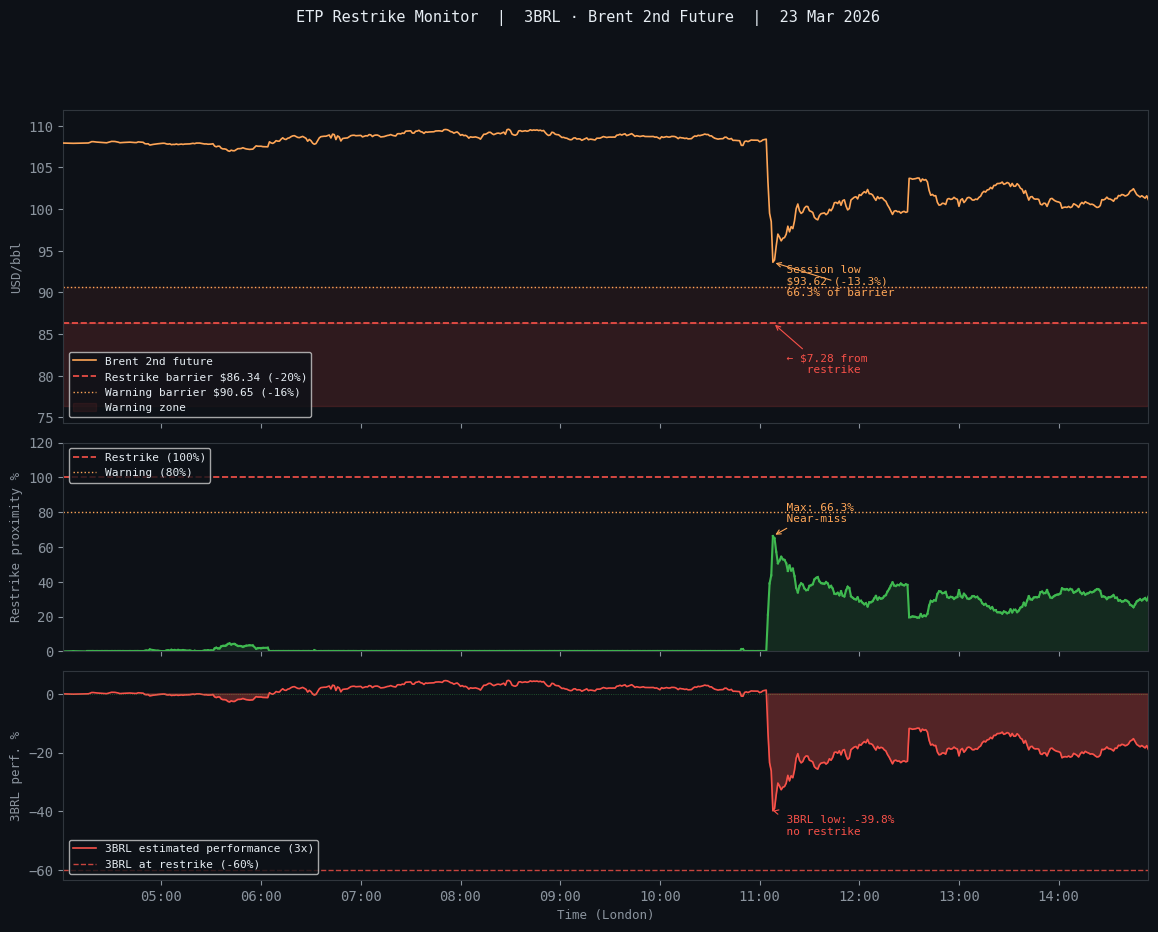

✓ Chart saved → assets/restrike_monitor.png


In [3]:
# ============================================================
# PLOT — Restrike Monitor Dashboard
# ============================================================

fig = plt.figure(figsize=(14, 10))
fig.suptitle(
    "ETP Restrike Monitor  |  3BRL · Brent 2nd Future  |  23 Mar 2026",
    fontsize=11, color='#e6edf3', y=0.98
)

gs = gridspec.GridSpec(3, 1, hspace=0.08, height_ratios=[3, 2, 2])

# --- Panel 1: Brent price + barriers ---
ax1 = fig.add_subplot(gs[0])
ax1.plot(df.index, df['close'], color='#ffa657', linewidth=1.2,
         label='Brent 2nd future', zorder=3)

# Restrike barrier
ax1.axhline(RESTRIKE_BARRIER, color='#f85149', linewidth=1.2,
            linestyle='--', label=f'Restrike barrier ${RESTRIKE_BARRIER:.2f} (-20%)', zorder=2)

# Warning barrier
ax1.axhline(WARN_BARRIER, color='#ffa657', linewidth=1,
            linestyle=':', label=f'Warning barrier ${WARN_BARRIER:.2f} (-16%)', zorder=2)

# Shade warning zone (between warn and restrike barriers)
ax1.axhspan(RESTRIKE_BARRIER, WARN_BARRIER,
            alpha=0.08, color='#f85149', label='Warning zone')

# Shade restrike zone (below restrike barrier)
ax1.axhspan(RESTRIKE_BARRIER - 10, RESTRIKE_BARRIER,
            alpha=0.15, color='#f85149')

# Annotate session low
low_idx = df['close'].idxmin()
low_price = df['close'].min()
ax1.annotate(
    f"  Session low\n  ${low_price:.2f} ({df['drawdown'].min():.1f}%)\n  66.3% of barrier",
    xy=(low_idx, low_price),
    xytext=(low_idx, low_price - 4),
    color='#ffa657', fontsize=8,
    arrowprops=dict(arrowstyle='->', color='#ffa657', lw=0.8)
)

# Near-miss annotation
ax1.annotate(
    f"  ← $7.28 from\n     restrike",
    xy=(low_idx, RESTRIKE_BARRIER),
    xytext=(low_idx, RESTRIKE_BARRIER - 6),
    color='#f85149', fontsize=8,
    arrowprops=dict(arrowstyle='->', color='#f85149', lw=0.8)
)

ax1.set_ylabel('USD/bbl', fontsize=9)
ax1.legend(fontsize=8, loc='lower left')
ax1.set_xticklabels([])
ax1.set_xlim(df.index[0], df.index[-1])
ax1.set_ylim(RESTRIKE_BARRIER - 12, OPEN_PRICE + 4)

# --- Panel 2: Restrike proximity gauge ---
ax2 = fig.add_subplot(gs[1])

# Color the proximity line by zone
for i in range(1, len(df)):
    prox = df['restrike_prox'].iloc[i]
    color = '#f85149' if prox >= 100 else '#ffa657' if prox >= 80 else '#3fb950'
    ax2.plot(df.index[i-1:i+1],
             df['restrike_prox'].iloc[i-1:i+1],
             color=color, linewidth=1.5)

ax2.fill_between(df.index, df['restrike_prox'],
                 alpha=0.15, color='#3fb950')

# Threshold lines
ax2.axhline(100, color='#f85149', linewidth=1.2, linestyle='--',
            label='Restrike (100%)')
ax2.axhline(80, color='#ffa657', linewidth=1, linestyle=':',
            label='Warning (80%)')

# Annotate max proximity
ax2.annotate(
    f"  Max: 66.3%\n  Near-miss",
    xy=(low_idx, df['restrike_prox'].max()),
    xytext=(low_idx, df['restrike_prox'].max() + 8),
    color='#ffa657', fontsize=8,
    arrowprops=dict(arrowstyle='->', color='#ffa657', lw=0.8)
)

ax2.set_ylabel('Restrike proximity %', fontsize=9)
ax2.set_ylim(0, 120)
ax2.legend(fontsize=8, loc='upper left')
ax2.set_xticklabels([])
ax2.set_xlim(df.index[0], df.index[-1])

# --- Panel 3: 3BRL estimated performance ---
ax3 = fig.add_subplot(gs[2])
ax3.fill_between(df.index, df['etp_perf'], 0,
                 where=df['etp_perf'] < 0,
                 color='#f85149', alpha=0.3)
ax3.plot(df.index, df['etp_perf'], color='#f85149', linewidth=1.2,
         label='3BRL estimated performance (3x)')
ax3.axhline(-60, color='#f85149', linewidth=1, linestyle='--',
            alpha=0.8, label='3BRL at restrike (-60%)')
ax3.axhline(0, color='#3fb950', linewidth=0.6, linestyle=':', alpha=0.5)

# Annotate 3BRL low
ax3.annotate(
    f"  3BRL low: {df['etp_perf'].min():.1f}%\n  no restrike",
    xy=(low_idx, df['etp_perf'].min()),
    xytext=(low_idx, df['etp_perf'].min() - 8),
    color='#f85149', fontsize=8,
    arrowprops=dict(arrowstyle='->', color='#f85149', lw=0.8)
)

ax3.set_ylabel('3BRL perf. %', fontsize=9)
ax3.set_xlabel('Time (London)', fontsize=9)
ax3.legend(fontsize=8, loc='lower left')
ax3.set_xlim(df.index[0], df.index[-1])

import matplotlib.dates as mdates
ax3.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax3.xaxis.set_major_locator(mdates.HourLocator())

plt.savefig('../assets/restrike_monitor.png', dpi=150,
            bbox_inches='tight', facecolor='#0d1117')
plt.savefig('restrike_monitor.png', dpi=150,
            bbox_inches='tight', facecolor='#0d1117')
plt.show()
print("✓ Chart saved → assets/restrike_monitor.png")

In [5]:
# ============================================================
# SUMMARY STATS
# ============================================================

low_price = df['close'].min()
low_drawdown = df['drawdown'].min()
max_prox = df['restrike_prox'].max()
margin_to_restrike = low_price - RESTRIKE_BARRIER
margin_pct = abs(RESTRIKE_THRESHOLD) - abs(low_drawdown)

print("=" * 52)
print("  RESTRIKE MONITOR — SESSION SUMMARY  |  23 Mar 2026")
print("=" * 52)
print(f"\n  UNDERLYING (Brent 2nd future proxy)")
print(f"  Open:                  ${OPEN_PRICE:.2f}")
print(f"  Session low:           ${low_price:.2f}  ({low_drawdown:.1f}%)")
print(f"  Restrike barrier:      ${RESTRIKE_BARRIER:.2f}  (-20%)")
print(f"  Warning barrier:       ${WARN_BARRIER:.2f}  (-16%)")
print(f"  Margin to restrike:    ${margin_to_restrike:.2f}  ({margin_pct:.1f}% remaining)")
print(f"  Max proximity:         {max_prox:.1f}%  — NOT triggered")
print(f"  Time in warning zone:  {(df['zone'] == 'warning').sum()} min")

print(f"\n  3BRL (3x DAILY — estimated)")
print(f"  Intraday low:          {df['etp_perf'].min():.1f}%")
print(f"  End of day:            {df['etp_perf'].iloc[-1]:.1f}%")
print(f"  At restrike would be:  -60%  (intraday reset triggered)")
print(f"  Restrike:              NOT triggered")

print(f"\n  NEAR-MISS ANALYSIS")
print(f"  Distance to barrier:   ${margin_to_restrike:.2f} ({margin_pct:.1f}%)")
print(f"  Scenario +5% more:     ${low_price * 0.95:.2f} → {'RESTRIKE' if low_price * 0.95 <= RESTRIKE_BARRIER else 'still safe'}")
print(f"  Scenario +8% more:     ${low_price * 0.92:.2f} → {'RESTRIKE' if low_price * 0.92 <= RESTRIKE_BARRIER else 'still safe'}")
print("=" * 52)

  RESTRIKE MONITOR — SESSION SUMMARY  |  23 Mar 2026

  UNDERLYING (Brent 2nd future proxy)
  Open:                  $107.92
  Session low:           $93.62  (-13.3%)
  Restrike barrier:      $86.34  (-20%)
  Warning barrier:       $90.65  (-16%)
  Margin to restrike:    $7.28  (6.7% remaining)
  Max proximity:         66.3%  — NOT triggered
  Time in warning zone:  0 min

  3BRL (3x DAILY — estimated)
  Intraday low:          -39.8%
  End of day:            -18.9%
  At restrike would be:  -60%  (intraday reset triggered)
  Restrike:              NOT triggered

  NEAR-MISS ANALYSIS
  Distance to barrier:   $7.28 (6.7%)
  Scenario +5% more:     $88.94 → still safe
  Scenario +8% more:     $86.13 → RESTRIKE


In [6]:
# ============================================================
# EXPORT HTML — GitHub Pages deployable
# ============================================================

html = f"""<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="UTF-8">
<meta name="viewport" content="width=device-width, initial-scale=1.0">
<title>ETP MM — Restrike Monitor | 23 Mar 2026</title>
<link href="https://fonts.googleapis.com/css2?family=JetBrains+Mono:wght@400;500&family=Inter:wght@400;500;600&display=swap" rel="stylesheet">
<style>
*{{margin:0;padding:0;box-sizing:border-box}}
body{{background:#0d1117;color:#e6edf3;font-family:'Inter',sans-serif;padding:32px 24px}}
.header{{max-width:900px;margin:0 auto 32px}}
.badge{{display:inline-block;background:#1c2128;border:1px solid #30363d;color:#8b949e;
  font-family:'JetBrains Mono',monospace;font-size:11px;padding:3px 10px;
  border-radius:4px;margin-bottom:12px}}
h1{{font-size:22px;font-weight:600;color:#e6edf3;margin-bottom:6px}}
.sub{{font-size:13px;color:#8b949e;font-family:'JetBrains Mono',monospace}}
.event-box{{max-width:900px;margin:0 auto 28px;background:#161b22;
  border:1px solid #30363d;border-left:3px solid #ffa657;
  border-radius:6px;padding:14px 18px}}
.event-box .time{{font-family:'JetBrains Mono',monospace;font-size:11px;
  color:#ffa657;margin-bottom:4px}}
.event-box p{{font-size:13px;color:#c9d1d9;line-height:1.6}}
.event-box strong{{color:#e6edf3}}
.grid{{max-width:900px;margin:0 auto 28px;
  display:grid;grid-template-columns:repeat(4,1fr);gap:12px}}
.card{{background:#161b22;border:1px solid #30363d;border-radius:8px;padding:16px}}
.card .label{{font-size:10px;color:#8b949e;text-transform:uppercase;
  letter-spacing:.6px;margin-bottom:6px;font-family:'JetBrains Mono',monospace}}
.card .value{{font-size:22px;font-weight:600}}
.card .delta{{font-size:11px;color:#8b949e;margin-top:4px}}
.red{{color:#f85149}}.orange{{color:#ffa657}}.green{{color:#3fb950}}.purple{{color:#bc8cff}}
.chart-wrap{{max-width:900px;margin:0 auto 28px;background:#161b22;
  border:1px solid #30363d;border-radius:8px;padding:20px}}
.chart-wrap img{{width:100%;border-radius:4px}}
.stats{{max-width:900px;margin:0 auto 28px;background:#161b22;
  border:1px solid #30363d;border-radius:8px;padding:20px}}
.stats h3{{font-size:13px;font-weight:600;color:#e6edf3;margin-bottom:14px;
  text-transform:uppercase;letter-spacing:.8px;font-family:'JetBrains Mono',monospace}}
.stat-row{{display:flex;justify-content:space-between;padding:8px 0;
  border-bottom:1px solid #21262d;font-size:13px}}
.stat-row:last-child{{border-bottom:none}}
.stat-label{{color:#8b949e}}
.stat-val{{font-family:'JetBrains Mono',monospace;color:#e6edf3;font-weight:500}}
.stat-val.red{{color:#f85149}}
.stat-val.orange{{color:#ffa657}}
.stat-val.green{{color:#3fb950}}
.scenario-box{{max-width:900px;margin:0 auto 28px;background:#161b22;
  border:1px solid #30363d;border-radius:8px;padding:20px}}
.scenario-box h3{{font-size:13px;font-weight:600;color:#e6edf3;margin-bottom:14px;
  text-transform:uppercase;letter-spacing:.8px;font-family:'JetBrains Mono',monospace}}
.scenario-row{{display:flex;justify-content:space-between;align-items:center;
  padding:10px 0;border-bottom:1px solid #21262d;font-size:13px}}
.scenario-row:last-child{{border-bottom:none}}
.scenario-label{{color:#8b949e}}
.scenario-badge{{font-family:'JetBrains Mono',monospace;font-size:11px;
  padding:3px 10px;border-radius:4px;font-weight:600}}
.badge-safe{{background:#0d2c0d;color:#3fb950;border:1px solid #1a4a1a}}
.badge-restrike{{background:#2c0000;color:#f85149;border:1px solid #4a0000}}
.badge-actual{{background:#2c1c00;color:#ffa657;border:1px solid #4a3000}}
.note{{max-width:900px;margin:0 auto 28px;background:#0d2c0d;
  border:1px solid #1a4a1a;border-radius:8px;padding:14px 18px;
  font-size:12px;color:#7ee787;line-height:1.7}}
.note strong{{color:#3fb950}}
footer{{max-width:900px;margin:32px auto 0;font-size:11px;
  color:#484f58;font-family:'JetBrains Mono',monospace;
  border-top:1px solid #21262d;padding-top:16px}}
</style>
</head>
<body>

<div class="header">
  <div class="badge">etp-market-making / 2_restrike_monitor</div>
  <h1>ETP Restrike Monitor</h1>
  <div class="sub">WisdomTree 3x Daily Brent Crude (3BRL) · ICE Brent 2nd month future · 23 March 2026</div>
</div>

<div class="event-box">
  <div class="time">11:08 London · Near-miss restrike event</div>
  <p>Brent 2nd future fell <strong>-13.3%</strong> to $93.62 — reaching <strong>66.3% of the -20% restrike barrier</strong>.
  Only <strong>$7.28 (6.7%) separated</strong> the session low from triggering an intraday reset on 3BRL.
  An additional -8% move on Brent would have breached $86.34 and triggered the restrike.</p>
</div>

<div class="grid">
  <div class="card">
    <div class="label">Max proximity</div>
    <div class="value orange">66.3%</div>
    <div class="delta">of -20% restrike barrier</div>
  </div>
  <div class="card">
    <div class="label">Margin to restrike</div>
    <div class="value green">$7.28</div>
    <div class="delta">6.7% remaining on underlying</div>
  </div>
  <div class="card">
    <div class="label">3BRL intraday low</div>
    <div class="value red">-39.8%</div>
    <div class="delta">no reset — restrike not triggered</div>
  </div>
  <div class="card">
    <div class="label">Restrike status</div>
    <div class="value green">Safe</div>
    <div class="delta">barrier at $86.34 not breached</div>
  </div>
</div>

<div class="chart-wrap">
  <img src="restrike_monitor.png" alt="Restrike Monitor — 3-panel dashboard">
</div>

<div class="stats">
  <h3>Session stats</h3>
  <div class="stat-row"><span class="stat-label">Open price</span><span class="stat-val">$107.92</span></div>
  <div class="stat-row"><span class="stat-label">Session low</span><span class="stat-val orange">$93.62  (-13.3%)</span></div>
  <div class="stat-row"><span class="stat-label">Restrike barrier</span><span class="stat-val">$86.34  (-20% on underlying)</span></div>
  <div class="stat-row"><span class="stat-label">Warning barrier</span><span class="stat-val">$90.65  (-16% on underlying)</span></div>
  <div class="stat-row"><span class="stat-label">Margin to restrike</span><span class="stat-val green">$7.28  (6.7% remaining)</span></div>
  <div class="stat-row"><span class="stat-label">Max restrike proximity</span><span class="stat-val orange">66.3%</span></div>
  <div class="stat-row"><span class="stat-label">Time in warning zone</span><span class="stat-val">0 min</span></div>
  <div class="stat-row"><span class="stat-label">3BRL intraday low (est.)</span><span class="stat-val red">-39.8%</span></div>
  <div class="stat-row"><span class="stat-label">3BRL end of day (est.)</span><span class="stat-val red">-18.9%</span></div>
  <div class="stat-row"><span class="stat-label">3BRL at restrike (would be)</span><span class="stat-val">-60%  → intraday reset</span></div>
  <div class="stat-row"><span class="stat-label">Restrike triggered</span><span class="stat-val green">No</span></div>
</div>

<div class="scenario-box">
  <h3>Near-miss scenario analysis</h3>
  <div class="scenario-row">
    <span class="scenario-label">Actual session low — $93.62 (-13.3%)</span>
    <span class="scenario-badge badge-actual">66.3% proximity</span>
  </div>
  <div class="scenario-row">
    <span class="scenario-label">+5% additional move — $88.94 (-17.6%)</span>
    <span class="scenario-badge badge-safe">Safe — 88% proximity</span>
  </div>
  <div class="scenario-row">
    <span class="scenario-label">+8% additional move — $86.13 (-20.2%)</span>
    <span class="scenario-badge badge-restrike">Restrike triggered</span>
  </div>
</div>

<div class="note">
  <strong>Restrike mechanics.</strong> The -20% trigger is measured on the
  <strong>underlying</strong> (ICE Brent 2nd month future), not on the 3BRL product itself.
  At -20% on the underlying, 3BRL would have lost ~60% intraday before the
  intraday reset — at which point a new base price is set and leverage recalculated
  from that point for the remainder of the session.
  Today's -13.3% on the underlying translated to -39.8% on 3BRL — no reset triggered,
  but a significant loss for holders purely from 3x leverage amplification.
</div>

<footer>
  Data: yfinance BZ=F (Brent 2nd future proxy) · 1-min intraday · 23 Mar 2026 ·
  Restrike monitor calibrated on WisdomTree 3BRL product specs ·
  github.com/Benjadeville/etp-mm
</footer>

</body>
</html>"""

with open("restrike_monitor.html", "w") as f:
    f.write(html)

print("✓ HTML exported → 2_restrike_monitor/restrike_monitor.html")
print("✓ Ready for GitHub Pages")

✓ HTML exported → 2_restrike_monitor/restrike_monitor.html
✓ Ready for GitHub Pages
